In [ ]:
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("arjunbasandrai/25-indian-bird-species-with-226k-images")

print("Path to dataset files:", path)

# The variable 'base_path' was not defined.
# Assuming 'base_path' was intended to be the parent directory of 'path'.
base_path = os.path.dirname(path)

print(f"Contents of base_path ({base_path}):\n{os.listdir(base_path)}")
print(f"Contents of path ({path}):\n{os.listdir(path)}")

100%|██████████| 9.33G/9.33G [07:38<00:00, 21.9MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4
Contents of base_path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions):
['4']
Contents of path (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4):
['training_data', 'training_set']


In [ ]:
print(f"Contents of the 'training_set' directory: {os.listdir(os.path.join(path, 'training_set'))}")
print(f"Contents of the 'training_data' directory: {os.listdir(os.path.join(path, 'training_data'))}")

Contents of the 'training_set' directory: ['training_set']
Contents of the 'training_data' directory: ['train', 'test', 'val']



--- Sample Images from training_set (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set) ---
Found 22620 images in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set. Displaying 6 samples:


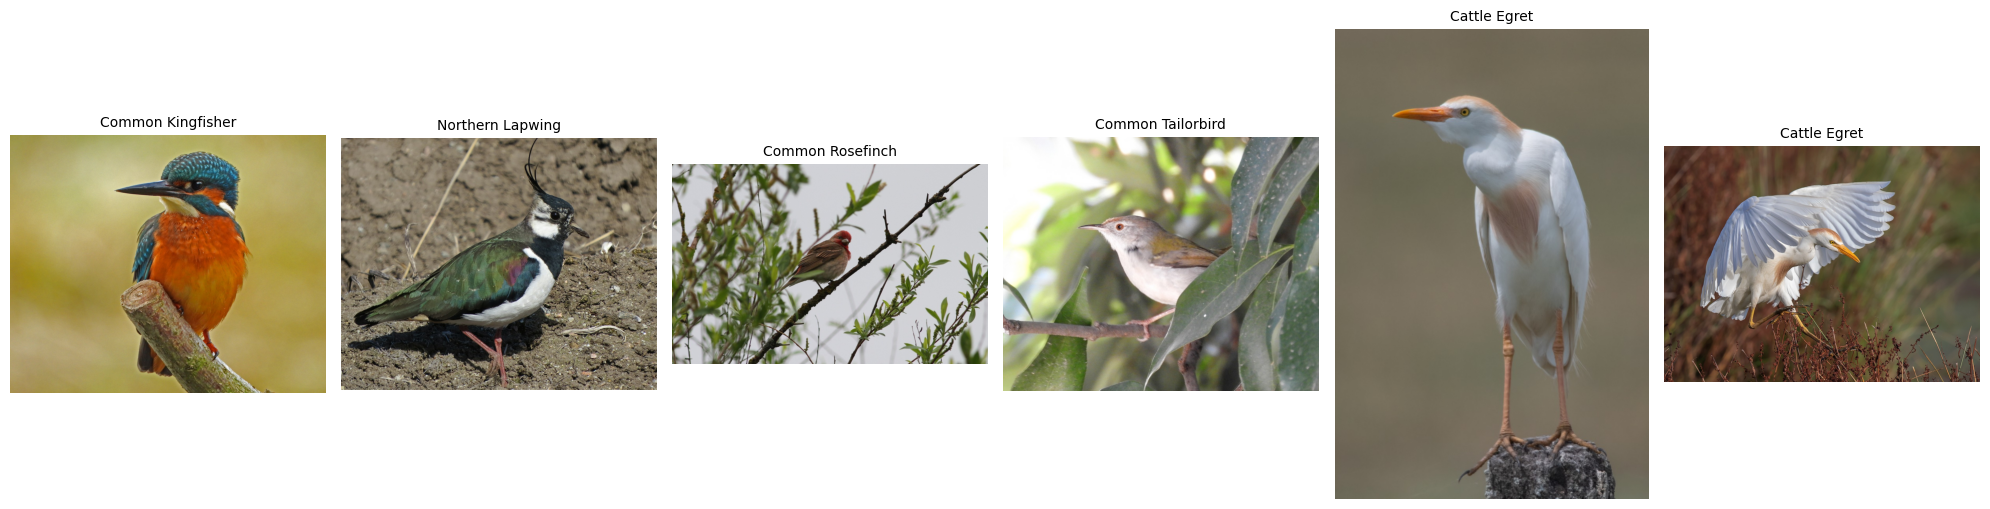


--- Sample Images from training_data (/root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data) ---
No images found in /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_data.


In [ ]:
import matplotlib.pyplot as plt
from PIL import Image
import random
import os

def display_sample_images(dataset_path, num_samples=6):
    image_extensions = ('.png', '.jpg', '.jpeg', '.gif', '.bmp')
    all_image_paths = []

    for root, dirs, files in os.walk(dataset_path):
        for file in files:
            if file.lower().endswith(image_extensions):
                all_image_paths.append(os.path.join(root, file))

    if not all_image_paths:
        print(f"No images found in {dataset_path}.")
        return

    print(f"Found {len(all_image_paths)} images in {dataset_path}. Displaying {min(num_samples, len(all_image_paths))} samples:")

    # Select random samples to display
    samples_to_display = random.sample(all_image_paths, min(len(all_image_paths), num_samples))

    fig, axes = plt.subplots(1, len(samples_to_display), figsize=(20, 5))
    if len(samples_to_display) == 1:
        axes = [axes]
    elif len(samples_to_display) == 0:
        plt.close(fig)
        return

    for i, img_path in enumerate(samples_to_display):
        try:
            img = Image.open(img_path)
            axes[i].imshow(img)
            # Extract species name from the directory name
            label = os.path.basename(os.path.dirname(img_path))
            axes[i].set_title(label, fontsize=10)
            axes[i].axis('off')
        except Exception as e:
            print(f"Error loading {img_path}: {e}")

    plt.tight_layout()
    plt.show()

# Updated paths to use the actual dataset folders found in cell IXEO7kTkTmB8
training_set_path = os.path.join(path, 'training_set')
print(f"\n--- Sample Images from training_set ({training_set_path}) ---")
display_sample_images(training_set_path)

training_data_path = os.path.join(path, 'training_data')
print(f"\n--- Sample Images from training_data ({training_data_path}) ---")
display_sample_images(training_data_path)


In [ ]:
import os

# Define the actual path containing the bird species folders
# Based on previous results, it is located in training_set/training_set
input_folder = os.path.join(path, 'training_set', 'training_set')
output_folder = '/content/bird_dataset_split'

if not os.path.exists(input_folder):
    # Fallback if the directory structure is not nested
    input_folder = os.path.join(path, 'training_set')

print(f"Preparing to split data from: {input_folder}")

Preparing to split data from: /root/.cache/kagglehub/datasets/arjunbasandrai/25-indian-bird-species-with-226k-images/versions/4/training_set/training_set


In [ ]:
!pip install split-folders

In [ ]:
import splitfolders

# Split the dataset: train=0.8, test=0.2
# seed=42 to ensure reproducibility
# We are splitting into train and val (using val as the test set as requested)
splitfolders.ratio(input_folder, output=output_folder, seed=42, ratio=(.8, .2), group_prefix=None, move=False)

print(f"Data split successfully into folder: {output_folder}")

Copying files: 22620 files [00:42, 535.99 files/s]

Data split successfully into folder: /content/bird_dataset_split


In [ ]:
# Check the directory structure after splitting
for root, dirs, files in os.walk(output_folder):
    level = root.replace(output_folder, '').count(os.sep)
    indent = ' ' * 4 * (level)
    if level <= 2: # Only print up to species level to avoid long output
        print(f"{indent}{os.path.basename(root)}/")

bird_dataset_split/
    train/
        Indian Grey Hornbill/
        Common Kingfisher/
        Jungle Babbler/
        Indian Roller/
        Brown-Headed Barbet/
        Common Myna/
        Rufous Treepie/
        Common Rosefinch/
        Sarus Crane/
        White-Breasted Kingfisher/
        Red-Wattled Lapwing/
        Cattle Egret/
        House Crow/
        Gray Wagtail/
        Common Tailorbird/
        White-Breasted Waterhen/
        Coppersmith Barbet/
        Ruddy Shelduck/
        Indian Pitta/
        Hoopoe/
        Indian Peacock/
        Northern Lapwing/
        Forest Wagtail/
        Asian Green Bee-Eater/
        White Wagtail/
    val/
        Indian Grey Hornbill/
        Common Kingfisher/
        Jungle Babbler/
        Indian Roller/
        Brown-Headed Barbet/
        Common Myna/
        Rufous Treepie/
        Common Rosefinch/
        Sarus Crane/
        White-Breasted Kingfisher/
        Red-Wattled Lapwing/
        Cattle Egret/
        House Crow

In [ ]:
import os

def count_files(directory):
    return sum([len(files) for r, d, files in os.walk(directory)])

train_count = count_files(os.path.join(output_folder, 'train'))
test_count = count_files(os.path.join(output_folder, 'val'))
total = train_count + test_count

print(f"New dataset statistics:")
print(f"- Train Set: {train_count} images ({train_count/total*100:.1f}%)")
print(f"- Test Set (val): {test_count} images ({test_count/total*100:.1f}%)")
print(f"- Total: {total} images")

New dataset statistics:
- Train Set: 18090 images (80.0%)
- Test Set (val): 4530 images (20.0%)
- Total: 22620 images


In [ ]:
import tensorflow as tf

# Check if GPU is available
print("TensorFlow version:", tf.__version__)
device_name = tf.test.gpu_device_name()
if device_name != '/device:GPU:0':
    print('GPU device not found. Please enable GPU in Colab settings.')
else:
    print('Found GPU at: {}'.format(device_name))

# Configure GPU memory growth to avoid allocation errors
gpus = tf.config.list_physical_devices('GPU')
if gpus:
    try:
        for gpu in gpus:
            tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print(e)

TensorFlow version: 2.20.0
Found GPU at: /device:GPU:0


In [ ]:
from tensorflow.keras.applications import InceptionV3
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras import layers, models, optimizers

# Configuration
IMG_SIZE = (299, 299)
BATCH_SIZE = 32
NUM_CLASSES = 25
EPOCHS = 10

# Data Generators
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    os.path.join(output_folder, 'train'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

val_generator = val_datagen.flow_from_directory(
    os.path.join(output_folder, 'val'),
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical'
)

# Build Model
base_model = InceptionV3(weights='imagenet', include_top=False, input_shape=(299, 299, 3))
base_model.trainable = False  # Freeze base layers for initial training

x = layers.GlobalAveragePooling2D()(base_model.output)
x = layers.Dense(512, activation='relu')(x)
x = layers.Dropout(0.3)(x)
predictions = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs=base_model.input, outputs=predictions)

model.compile(optimizer=optimizers.Adam(learning_rate=0.001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train Model
print("Starting training...")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    verbose=1
)

Found 18090 images belonging to 25 classes.
Found 4530 images belonging to 25 classes.
87910968/87910968 ━━━━━━━━━━━━━━━━━━━━ 5s 0us/step
Starting training...
Epoch 1/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 836s 1s/step - accuracy: 0.7711 - loss: 0.7797 - val_accuracy: 0.8832 - val_loss: 0.3977
Epoch 2/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 768s 1s/step - accuracy: 0.8624 - loss: 0.4559 - val_accuracy: 0.9106 - val_loss: 0.2956
Epoch 3/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 746s 1s/step - accuracy: 0.8737 - loss: 0.4064 - val_accuracy: 0.9139 - val_loss: 0.2880
Epoch 4/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 752s 1s/step - accuracy: 0.8865 - loss: 0.3661 - val_accuracy: 0.9159 - val_loss: 0.2828
Epoch 5/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 761s 1s/step - accuracy: 0.8903 - loss: 0.3467 - val_accuracy: 0.9091 - val_loss: 0.3026
Epoch 6/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 734s 1s/step - accuracy: 0.8949 - loss: 0.3375 - val_accuracy: 0.9146 - val_loss: 0.2852
Epoch 7/10
566/566 ━━━━━━━━━━━━━━━━━━━━ 721s 1s/step - accuracy: 0.

In [ ]:
# Evaluate and summarize results
val_loss, val_acc = model.evaluate(val_generator)
print(f"\n--- Training Summary ---")
print(f"Final Training Accuracy: {history.history['accuracy'][-1]*100:.2f}%")
print(f"Final Validation Accuracy: {val_acc*100:.2f}%")
print(f"Final Training Loss: {history.history['loss'][-1]:.4f}")
print(f"Final Validation Loss: {val_loss:.4f}")

142/142 ━━━━━━━━━━━━━━━━━━━━ 84s 591ms/step - accuracy: 0.9241 - loss: 0.2674

--- Training Summary ---
Final Training Accuracy: 90.75%
Final Validation Accuracy: 92.41%
Final Training Loss: 0.2852
Final Validation Loss: 0.2674


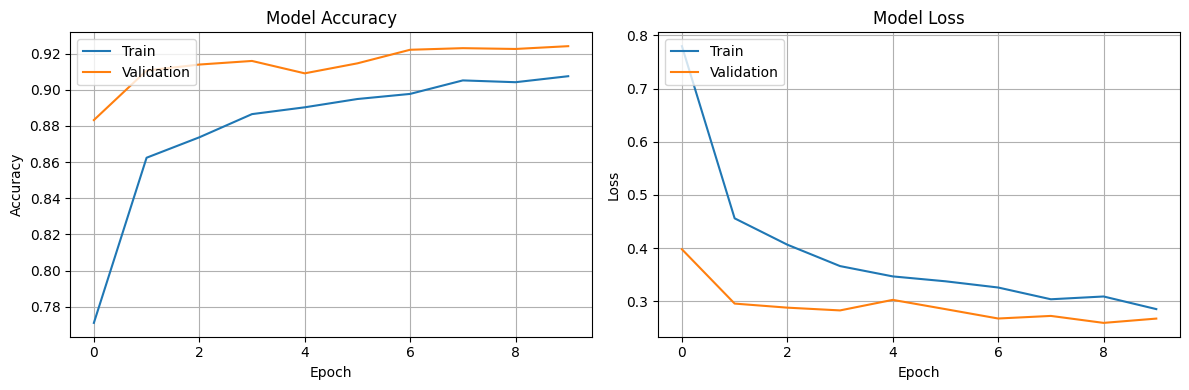

In [ ]:
import matplotlib.pyplot as plt

# Plot training & validation accuracy values
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

# Plot training & validation loss values
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Model Loss')
plt.ylabel('Loss')
plt.xlabel('Epoch')
plt.legend(['Train', 'Validation'], loc='upper left')
plt.grid(True)

plt.tight_layout()
plt.show()